<a href="https://colab.research.google.com/github/arunkamalcloud/arunkamalcloud/blob/main/Compliance_IQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regulatory Compliance Multi-Agent System
## Capstone Assignment - 8-Week Progressive Exercise

**Course**: Agentic AI Bootcamp - Staff-Level System Design

---

## Assignment Overview

In this capstone assignment, you will build a **production-grade multi-agent regulatory compliance system** for the insurance industry that analyzes company policies against regulatory requirements, identifies compliance gaps, and provides remediation recommendations.

### What You Will Build

| Component | Description |
|-----------|-------------|
| **PDF/DOCX Regulation Parser** | Extract text and tables from regulatory documents |
| **Requirement Extractor** | Use regex patterns to identify mandatory requirements |
| **Gap Detector Agent** | Compare regulations against company policies |
| **Compliance Scoring System** | Calculate domain-level compliance scores |
| **Regulatory Knowledge Graph** | Map relationships between regulations, domains, and policies |

### Dataset Overview

| Category | Files | Description |
|----------|-------|-------------|
| **Regulatory PDFs** | 14 PDFs | IRDAI regulations, MAS guidelines, audit controls |
| **Company Policies** | 8 DOCX | Internal policies (Governance, Risk, Underwriting, Cyber) |
| **Regulatory Sources** | 1 DOCX | Reference list of regulatory sources |

### 8-Week Structure

| Week | Module | Difficulty |
|------|--------|------------|
| 1 | Environment & Data Loading | Beginner |
| 2 | Document Processing & EDA | Beginner |
| 3 | Vector Store & Embeddings | Intermediate |
| 4 | Single Agent Design | Intermediate |
| 5 | Multi-Agent Orchestration | Advanced |
| 6 | Compliance Knowledge Graph | Advanced |
| 7 | Advanced Observability | Expert |
| 8 | Production Deployment | Expert |

### Grading Rubric

- **Functionality (40%)**: All components work correctly
- **Code Quality (20%)**: Clean, documented, follows best practices
- **Observability (20%)**: Proper Langfuse tracing throughout
- **Compliance Domain (20%)**: Correct regulatory logic and gap detection

---
# WEEK 1: Environment Setup & Data Loading
---

## Learning Objectives
- Configure development environment in Google Colab
- Initialize Langfuse observability from the start
- Load and explore regulatory documents

## Difficulty: Beginner

**HINT**: Environment setup is foundational. Pay attention to:
- Colab vs local environment detection
- Secure API key handling
- Data directory path configuration for regulations and policies

In [1]:
# ============================================================================
# WEEK 1: ENVIRONMENT SETUP (PROVIDED - Run this cell as-is)
# ============================================================================

# Install required packages
!pip install -q langchain==0.3.14 langchain-openai==0.3.0 langchain-community==0.3.14
!pip install -q langfuse==2.57.1 openai==1.59.6
!pip install -q chromadb==0.5.23
!pip install -q networkx==3.4.2 pyvis==0.3.2
!pip install -q python-docx pdfplumber PyPDF2
!pip install -q plotly
!pip install -q pydantic tenacity rich gradio python-dotenv

print("All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph 1.1.9 requires langchain-core<2,>=1.3.0, but you have langchain-core 0.3.63 which is incompatible.
langgraph-prebuilt 1.0.10 requires langchain-core>=1.0.0, but you have langchain-core

In [2]:
# ============================================================================
# IMPORTS AND ENVIRONMENT DETECTION (PROVIDED)
# ============================================================================

import os
import sys
import json
import re
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Optional, Any, Tuple
from dataclasses import dataclass
from enum import Enum
import warnings
warnings.filterwarnings('ignore')

# Environment Detection
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab environment")
    from google.colab import drive
    drive.mount('/content/drive')

    try:
        from google.colab import userdata
        os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
        os.environ['LANGFUSE_SECRET_KEY'] = userdata.get('LANGFUSE_SECRET_KEY')
        os.environ['LANGFUSE_PUBLIC_KEY'] = userdata.get('LANGFUSE_PUBLIC_KEY')
        os.environ['LANGFUSE_HOST'] = userdata.get('LANGFUSE_HOST') or 'https://cloud.langfuse.com'
        print("API keys loaded from Colab Secrets")
    except Exception as e:
        print(f"Colab Secrets not available: {e}")
        import getpass
        os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter OpenAI API Key: ')
        os.environ['LANGFUSE_SECRET_KEY'] = getpass.getpass('Enter Langfuse Secret Key: ')
        os.environ['LANGFUSE_PUBLIC_KEY'] = getpass.getpass('Enter Langfuse Public Key: ')
        os.environ['LANGFUSE_HOST'] = 'https://cloud.langfuse.com'

    # DATA_DIR_BASE = '/content/drive/MyDrive/pwc-agenticai-capstone/datasets/regulatory_compliance'
    # My Drive
    DATA_DIR_BASE = "/content/drive/MyDrive/Colab Notebooks/ComplianceIQ/Datasets"
    REGULATIONS_DIR_BASE = f'{DATA_DIR_BASE}/Regulations'
    POLICIES_DIR_BASE = f'{DATA_DIR_BASE}/Company Policies sample documents'
else:
    print("Running in local environment")
    from dotenv import load_dotenv
    load_dotenv()

    DATA_DIR_BASE = str(Path('.').resolve().parent.parent / 'datasets' / 'regulatory_compliance')
    REGULATIONS_DIR_BASE = f'{DATA_DIR_BASE}/Regulations'
    POLICIES_DIR_BASE = f'{DATA_DIR_BASE}/Company Policies sample documents'

# Validate environment
assert os.environ.get('OPENAI_API_KEY'), "OPENAI_API_KEY not found"
assert os.environ.get('LANGFUSE_SECRET_KEY'), "LANGFUSE_SECRET_KEY not found"

PROJECT_NAME = "regulatory-compliance-system"
DATA_DIR = Path(DATA_DIR_BASE)
REGULATIONS_DIR = Path(REGULATIONS_DIR_BASE)
POLICIES_DIR = Path(POLICIES_DIR_BASE)

print(f"\nProject: {PROJECT_NAME}")
print(f"Regulations Directory: {REGULATIONS_DIR}")
print(f"Policies Directory: {POLICIES_DIR}")

Running in Google Colab environment
Mounted at /content/drive
API keys loaded from Colab Secrets

Project: regulatory-compliance-system
Regulations Directory: /content/drive/MyDrive/Colab Notebooks/ComplianceIQ/Datasets/Regulations
Policies Directory: /content/drive/MyDrive/Colab Notebooks/ComplianceIQ/Datasets/Company Policies sample documents


In [33]:
import os
os.environ['CHROMA_ANALYTICS_ENABLED'] = 'False'
print("ChromaDB analytics disabled.")

ChromaDB analytics disabled.


In [3]:
# ============================================================================
# TODO 1.1: INITIALIZE LANGFUSE CLIENT
# ============================================================================
#
# Your task: Initialize Langfuse for observability tracking
#
# INSTRUCTIONS:
# 1. Import Langfuse and LangfuseCallbackHandler
# 2. Create a Langfuse client with proper credentials
# 3. Verify the connection with auth_check()
# 4. Create a unique SESSION_ID for this notebook run
#
# HINT: Use os.environ.get() to retrieve credentials
#
# EXPECTED OUTPUT:
# - "Langfuse connected successfully!"
# - Session ID in format: compliance-YYYYMMDD-HHMMSS
# ============================================================================

from langfuse import Langfuse
from langfuse.callback import CallbackHandler as LangfuseCallbackHandler
from openai import OpenAI

# TODO: Initialize Langfuse client
langfuse = Langfuse(
    secret_key=os.environ.get('LANGFUSE_SECRET_KEY'),
    public_key=os.environ.get('LANGFUSE_PUBLIC_KEY'),
    host=os.environ.get('LANGFUSE_HOST')
)

# TODO: Verify connection
langfuse.auth_check()
print("Langfuse connected successfully!")

# TODO: Create session ID
SESSION_ID = f"compliance-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

# Initialize OpenAI client
openai_client = OpenAI()

print(f"Session ID: {SESSION_ID}")

Langfuse connected successfully!
Session ID: compliance-20260502-064611


In [4]:
# ============================================================================
# VALIDATION CELL 1.1: Verify Langfuse Setup
# ============================================================================

def validate_langfuse_setup():
    """Validate that Langfuse is properly configured."""
    errors = []

    if langfuse is None:
        errors.append("Langfuse client not initialized")
    else:
        try:
            langfuse.auth_check()
        except Exception as e:
            errors.append(f"Langfuse auth failed: {e}")

    if not SESSION_ID.startswith("compliance-"):
        errors.append("SESSION_ID should start with 'compliance-'")

    if errors:
        print("VALIDATION FAILED:")
        for e in errors:
            print(f"  - {e}")
        return False

    print("VALIDATION PASSED: Langfuse setup correct!")
    return True

validate_langfuse_setup()

VALIDATION PASSED: Langfuse setup correct!


True

In [42]:
from langfuse import Langfuse
from langfuse.callback import CallbackHandler as LangfuseCallbackHandler
from openai import OpenAI
from tenacity import retry, stop_after_attempt, wait_exponential # Import retry functionalities

@retry(stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=4, max=10))
def traced_embedding(text: str, trace_name: str = "embedding", metadata: Dict = None) -> List[float]:
    """
    Generate embedding with full Langfuse tracing.

    Args:
        text: The text to embed
        trace_name: Name for the Langfuse trace
        metadata: Optional metadata dictionary

    Returns:
        List of floats representing the embedding vector
    """
    # 1. Create a Langfuse trace with session_id and metadata
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, tags=["embedding", "compliance"], metadata=metadata or {})

    # 2. Create a generation span for the embedding call
    generation = trace.generation(name="openai-embedding", model="text-embedding-3-small", input=text[:500])

    # 3. Call OpenAI embeddings API (model: text-embedding-3-small)
    response = openai_client.embeddings.create(model="text-embedding-3-small", input=text[:8000])
    embedding = response.data[0].embedding

    # 4. End the generation with usage stats
    generation.end(output={"dimensions": len(embedding)}, usage={"input": response.usage.prompt_tokens})

    # 5. Return the embedding
    return embedding

def traced_completion(prompt: str, trace_name: str = "completion",
                      model: str = "gpt-4o-mini", metadata: Dict = None) -> str:
    """
    Generate completion with full Langfuse tracing.

    Args:
        prompt: User prompt
        trace_name: Name for the trace
        model: OpenAI model to use
        metadata: Optional metadata

    Returns:
        The completion text
    """
    # 1. Create a Langfuse trace
    trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, tags=["completion", "compliance"], metadata=metadata or {})

    # 2. Create generation span
    generation = trace.generation(name="openai-completion", model=model, input=prompt[:500])

    # 3. Call OpenAI chat completions API
    response = openai_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    completion_text = response.choices[0].message.content

    # 4. End generation with output and token usage
    generation.end(
        output=completion_text,
        usage={
            "input": response.usage.prompt_tokens,
            "output": response.usage.completion_tokens
        }
    )

    # 5. Return result
    return completion_text


def get_langfuse_handler(trace_name: str, tags: List[str] = None) -> LangfuseCallbackHandler:
    """
    Get a LangChain callback handler for automatic tracing.

    Args:
        trace_name: Name for the trace
        tags: Optional list of tags

    Returns:
        LangfuseCallbackHandler instance
    """
    # Return a LangfuseCallbackHandler with proper credentials and session_id
    return LangfuseCallbackHandler(
        public_key=os.environ.get('LANGFUSE_PUBLIC_KEY'),
        secret_key=os.environ.get('LANGFUSE_SECRET_KEY'),
        host=os.environ.get('LANGFUSE_HOST'),
        session_id=SESSION_ID,
        trace_name=trace_name,
        tags=tags
    )


print("Traced helper functions defined and implemented.")

Traced helper functions defined and implemented.


In [6]:
# ============================================================================
# TODO 1.3: DEFINE COMPLIANCE TAXONOMY
# ============================================================================
#
# Your task: Define the compliance domain taxonomy
#
# INSTRUCTIONS:
# Complete the COMPLIANCE_DOMAINS dictionary with:
# 1. Description of each domain
# 2. Related regulations for each domain
# 3. Related policies for each domain
# 4. Risk weight (0.0 to 1.0) indicating importance
#
# COMPLIANCE DOMAINS TO COVER:
# - governance: Board oversight, corporate structure
# - risk_management: Risk frameworks, assessments
# - information_security: Cybersecurity, data protection
# - claims_management: Claims processing, grievances
# - reinsurance: Reinsurance operations
# - audit: Internal audit, controls
# - sales_distribution: Sales practices, conduct
# - investments: Investment management
# - fraud: Fraud prevention
# ============================================================================

COMPLIANCE_DOMAINS = {
    'governance': {
        'description': 'Corporate governance and structure',
        'regulations': ['corporate-governance-guidelines'],
        'policies': ['Governance and Corporate Structure'],
        'risk_weight': 0.9
    },
    'risk_management': {
        'description': 'Risk management frameworks',
        'regulations': ['risk-management-framework', 'mas-guidelines-risk-management'],  # Added relevant regulations
        'policies': ['Enterprise Risk Management Policy', 'Operational Risk Policy'],  # Added relevant policies
        'risk_weight': 0.95
    },
    # TODO: Add remaining domains:
    # - information_security
    # - claims_management
    # - reinsurance
    # - audit
    # - sales_distribution
    # - investments
    # - fraud
    'information_security': {
        'description': 'Data protection and cybersecurity measures',
        'regulations': ['information-security-guidelines', 'gdpr-compliance'],
        'policies': ['Information Security Policy', 'Data Privacy Policy'],
        'risk_weight': 0.85
    },
    'claims_management': {
        'description': 'Processing and managing insurance claims',
        'regulations': ['claims-handling-regulations', 'irda-claims-guidelines'],
        'policies': ['Claims Procedure Manual', 'Customer Grievance Policy'],
        'risk_weight': 0.75
    },
    'reinsurance': {
        'description': 'Reinsurance operations and arrangements',
        'regulations': ['reinsurance-regulations', 'irda-reinsurance-rules'],
        'policies': ['Reinsurance Strategy', 'Treaty Management Policy'],
        'risk_weight': 0.7
    },
    'audit': {
        'description': 'Internal and external audit processes',
        'regulations': ['internal-audit-standards', 'audit-control-framework'],
        'policies': ['Internal Audit Charter', 'Compliance Audit Program'],
        'risk_weight': 0.8
    },
    'sales_distribution': {
        'description': 'Sales practices and distribution channels',
        'regulations': ['market-conduct-regulations', 'sales-force-guidelines'],
        'policies': ['Sales Code of Conduct', 'Distribution Partner Agreement'],
        'risk_weight': 0.65
    },
    'investments': {
        'description': 'Investment management and portfolio governance',
        'regulations': ['investment-regulations', 'capital-adequacy-rules'],
        'policies': ['Investment Policy Statement', 'Asset-Liability Management'],
        'risk_weight': 0.88
    },
    'fraud': {
        'description': 'Prevention, detection, and investigation of fraud',
        'regulations': ['anti-fraud-legislation', 'aml-guidelines'],
        'policies': ['Anti-Fraud Policy', 'Whistleblower Policy'],
        'risk_weight': 0.92
    }
}

print("Compliance Domains defined:")
for domain, info in COMPLIANCE_DOMAINS.items():
    print(f"  - {domain}: {info['description']} (risk weight: {info['risk_weight']})")

Compliance Domains defined:
  - governance: Corporate governance and structure (risk weight: 0.9)
  - risk_management: Risk management frameworks (risk weight: 0.95)
  - information_security: Data protection and cybersecurity measures (risk weight: 0.85)
  - claims_management: Processing and managing insurance claims (risk weight: 0.75)
  - reinsurance: Reinsurance operations and arrangements (risk weight: 0.7)
  - audit: Internal and external audit processes (risk weight: 0.8)
  - sales_distribution: Sales practices and distribution channels (risk weight: 0.65)
  - investments: Investment management and portfolio governance (risk weight: 0.88)
  - fraud: Prevention, detection, and investigation of fraud (risk weight: 0.92)


In [7]:
# ============================================================================
# TODO 1.4: DISCOVER REGULATORY DATA FILES
# ============================================================================
#
# Your task: Implement a function to discover all regulatory documents
#
# INSTRUCTIONS:
# 1. Search REGULATIONS_DIR for PDF files
# 2. Search POLICIES_DIR for DOCX files
# 3. Return dictionary with 'regulations' and 'policies' keys
#
# COMPLIANCE HINT: Document inventory is essential for:
# - Regulatory audit trails
# - Coverage analysis
# - Gap identification
#
# EXPECTED OUTPUT:
# Dictionary with lists of Path objects for regulations and policies
# ============================================================================

def discover_compliance_data(regulations_dir: Path, policies_dir: Path) -> Dict:
    """
    Discover all regulatory and policy documents.

    Args:
        regulations_dir: Directory containing regulatory PDFs
        policies_dir: Directory containing policy DOCX files

    Returns:
        Dictionary with 'regulations' and 'policies' lists
    """
    discovered = {'regulations': [], 'policies': []}

    # TODO: Discover regulation PDFs
    # HINT: Use regulations_dir.glob('*.pdf')
    if regulations_dir.exists():
        # YOUR CODE HERE
        discovered['regulations'] = list(regulations_dir.glob('*.pdf'))

    # TODO: Discover policy DOCX files
    # HINT: Use policies_dir.glob('*.docx')
    if policies_dir.exists():
        # YOUR CODE HERE
        discovered['policies'] = list(policies_dir.glob('*.docx'))

    return discovered


# Discover documents with tracing
if langfuse:
    trace = langfuse.trace(
        name="discover-documents",
        session_id=SESSION_ID,
        tags=["discovery", "documents"]
    )

compliance_files = discover_compliance_data(REGULATIONS_DIR, POLICIES_DIR)

print("\nREGULATORY COMPLIANCE DOCUMENTS")
print("=" * 60)
print(f"\nRegulations (PDFs): {len(compliance_files['regulations'])}")
for f in compliance_files['regulations'][:5]:
    print(f"  - {f.name}")
if len(compliance_files['regulations']) > 5:
    print(f"  ... and {len(compliance_files['regulations']) - 5} more")

print(f"\nCompany Policies (DOCX): {len(compliance_files['policies'])}")
for f in compliance_files['policies']:
    print(f"  - {f.name}")


REGULATORY COMPLIANCE DOCUMENTS

Regulations (PDFs): 14
  - MAS Risk management Guidelines.pdf
  - fraud-risk-framework 1.pdf
  - Fraud Prevention 2.pdf
  - Grievance+Redressal+Policy 3.pdf
  - Audit COntol for Insurance Companies.pdf
  ... and 9 more

Company Policies (DOCX): 8
  - Non Proportional Reinsurance Agreement.docx
  - Quota Share Reinsurance Agreement.docx
  - Underwriting and Risk Assessment.docx
  - Cyber Insurance Policy Document.docx
  - Governance and Corporate Structure for an Insurance Company.docx
  - Specimen Reinsurance Agreement SEC.docx
  - Surplus Share Reinsurance Agreement.docx
  - Risk Management and Compliance for an Insurance Company.docx


---
# WEEK 2: Document Processing & EDA
---

## Learning Objectives
- Parse regulatory PDFs and policy DOCX files
- Extract structured information from documents
- Implement requirement extraction with regex

## Difficulty: Beginner to Intermediate

**COMPLIANCE CHALLENGE**: Regulatory documents have:
- Legal language with "shall", "must", "required" keywords
- Complex nested requirements
- Tables with compliance criteria
- Section/subsection hierarchies

In [20]:
import pdfplumber
from docx import Document as DocxDocument

class RegulatoryDocumentProcessor:
    """
    Process regulatory PDFs and company policy documents.
    All operations traced to Langfuse.
    """

    def __init__(self):
        self.processed_docs = []

    def load_pdf(self, file_path: Path) -> Dict:
        """
        Extract text and tables from regulatory PDF.

        TODO:
        1. Open PDF with pdfplumber
        2. Extract text from each page
        3. Extract tables from each page
        4. Return structured dictionary

        HINT:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                tables = page.extract_tables()
        """
        try:
            text_content = []
            tables_data = []

            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    text = page.extract_text()
                    if text:
                        text_content.append(text)
                    raw_tables = page.extract_tables()
                    for table in raw_tables:
                        if table:
                            tables_data.append(table)

            full_text = '\n'.join(text_content)
            result = {
                'filename': file_path.name,
                'format': 'pdf',
                'doc_type': 'regulation',
                'full_text': full_text,
                'tables': tables_data,
                'page_count': len(pdf.pages),
                'char_count': len(full_text),
                'table_count': len(tables_data)
            }
            return result
        except Exception as e:
            print(f"Error loading PDF {file_path.name}: {e}")
            return None

    def load_docx(self, file_path: Path) -> Dict:
        """
        Extract text and tables from policy DOCX.

        TODO:
        1. Open document with python-docx
        2. Extract all paragraphs (filter empty ones)
        3. Extract all tables as lists of rows
        4. Return structured dictionary

        HINT for tables:
        for table in doc.tables:
            for row in table.rows:
                row_data = [cell.text.strip() for cell in row.cells]
        """
        try:
            doc = DocxDocument(file_path)
            paragraphs = []
            for p in doc.paragraphs:
                if p.text.strip():
                    paragraphs.append(p.text.strip())

            tables_data = []
            for table in doc.tables:
                current_table = []
                for row in table.rows:
                    row_data = [cell.text.strip() for cell in row.cells]
                    current_table.append(row_data)
                if current_table:
                    tables_data.append(current_table)

            full_text = '\n'.join(paragraphs)
            result = {
                'filename': file_path.name,
                'format': 'docx',
                'doc_type': 'policy',
                'full_text': full_text,
                'tables': tables_data,
                'section_count': len(paragraphs),
                'char_count': len(full_text),
                'table_count': len(tables_data)
            }
            return result
        except Exception as e:
            print(f"Error loading DOCX {file_path.name}: {e}")
            return None

    def process_all(self, files: Dict) -> Dict:
        """
        Process all regulatory and policy documents.

        TODO:
        1. Process all regulation PDFs
        2. Process all policy DOCX files
        3. Assign doc_id to each document (REG-001, POL-001, etc.)
        4. Add Langfuse tracing
        """
        processed = {'regulations': [], 'policies': []}

        # Explicitly create the trace for regulations processing
        regulations_trace = langfuse.trace(name="process-regulations", session_id=SESSION_ID, tags=["data_processing", "regulations"])
        try:
            for pdf_path in files.get('regulations', []):
                # Use explicit span start/end to avoid TypeError with context manager
                span_reg_doc = regulations_trace.span(name=f"process-pdf-{pdf_path.name}")
                try:
                    doc = self.load_pdf(pdf_path)
                    if doc:
                        doc['doc_id'] = f"REG-{len(processed['regulations'])+1:03d}"
                        processed['regulations'].append(doc)
                finally:
                    span_reg_doc.end()
        except Exception as e:
            regulations_trace.update(status='ERROR', status_message=str(e))
            raise # Re-raise the exception after updating the trace
        finally:
            # Only end if the trace object has an 'end' method
            if hasattr(regulations_trace, 'end'):
                regulations_trace.end()


        # Explicitly create the trace for policies processing
        policies_trace = langfuse.trace(name="process-policies", session_id=SESSION_ID, tags=["data_processing", "policies"])
        try:
            for docx_path in files.get('policies', []):
                # Use explicit span start/end to avoid TypeError with context manager
                span_pol_doc = policies_trace.span(name=f"process-docx-{docx_path.name}")
                try:
                    doc = self.load_docx(docx_path)
                    if doc:
                        doc['doc_id'] = f"POL-{len(processed['policies'])+1:03d}"
                        processed['policies'].append(doc)
                finally:
                    span_pol_doc.end()
        except Exception as e:
            policies_trace.update(status='ERROR', status_message=str(e))
            raise # Re-raise the exception after updating the trace
        finally:
            # Only end if the trace object has an 'end' method
            if hasattr(policies_trace, 'end'):
                policies_trace.end()

        return processed


# Initialize and process documents
doc_processor = RegulatoryDocumentProcessor()
all_compliance_docs = doc_processor.process_all(compliance_files)

print(f"Processed {len(all_compliance_docs['regulations'])} regulations")
print(f"Processed {len(all_compliance_docs['policies'])} policies")

Processed 14 regulations
Processed 8 policies


REGULATORY DOCUMENTS ANALYSIS
 doc_id                                 filename  pages  chars  tables
REG-001       MAS Risk management Guidelines.pdf     24  48719       0
REG-002               fraud-risk-framework 1.pdf     24  50268       5
REG-003                   Fraud Prevention 2.pdf     14  23305       0
REG-004         Grievance+Redressal+Policy 3.pdf      5  11227       0
REG-005 Audit COntol for Insurance Companies.pdf     15  47091       5
REG-006               Internal Audit of GICs.pdf    128 234692      13
REG-007 MAS Standards of Conduct for Marketing a     20  37089       2
REG-008         grievance redressal policy-2.pdf     10  15902       3
REG-009 Insurer Investments and Financial Manage     56 176108       5
REG-010 Information security Guidelines for insu     80 141585      19
REG-011 corporate-governance-guidelines-for-rein     34  62951       0
REG-012 Guide for Insurance Sales Advisory and D     48 116028     101
REG-013         grievance-redressal-policy-1.pd

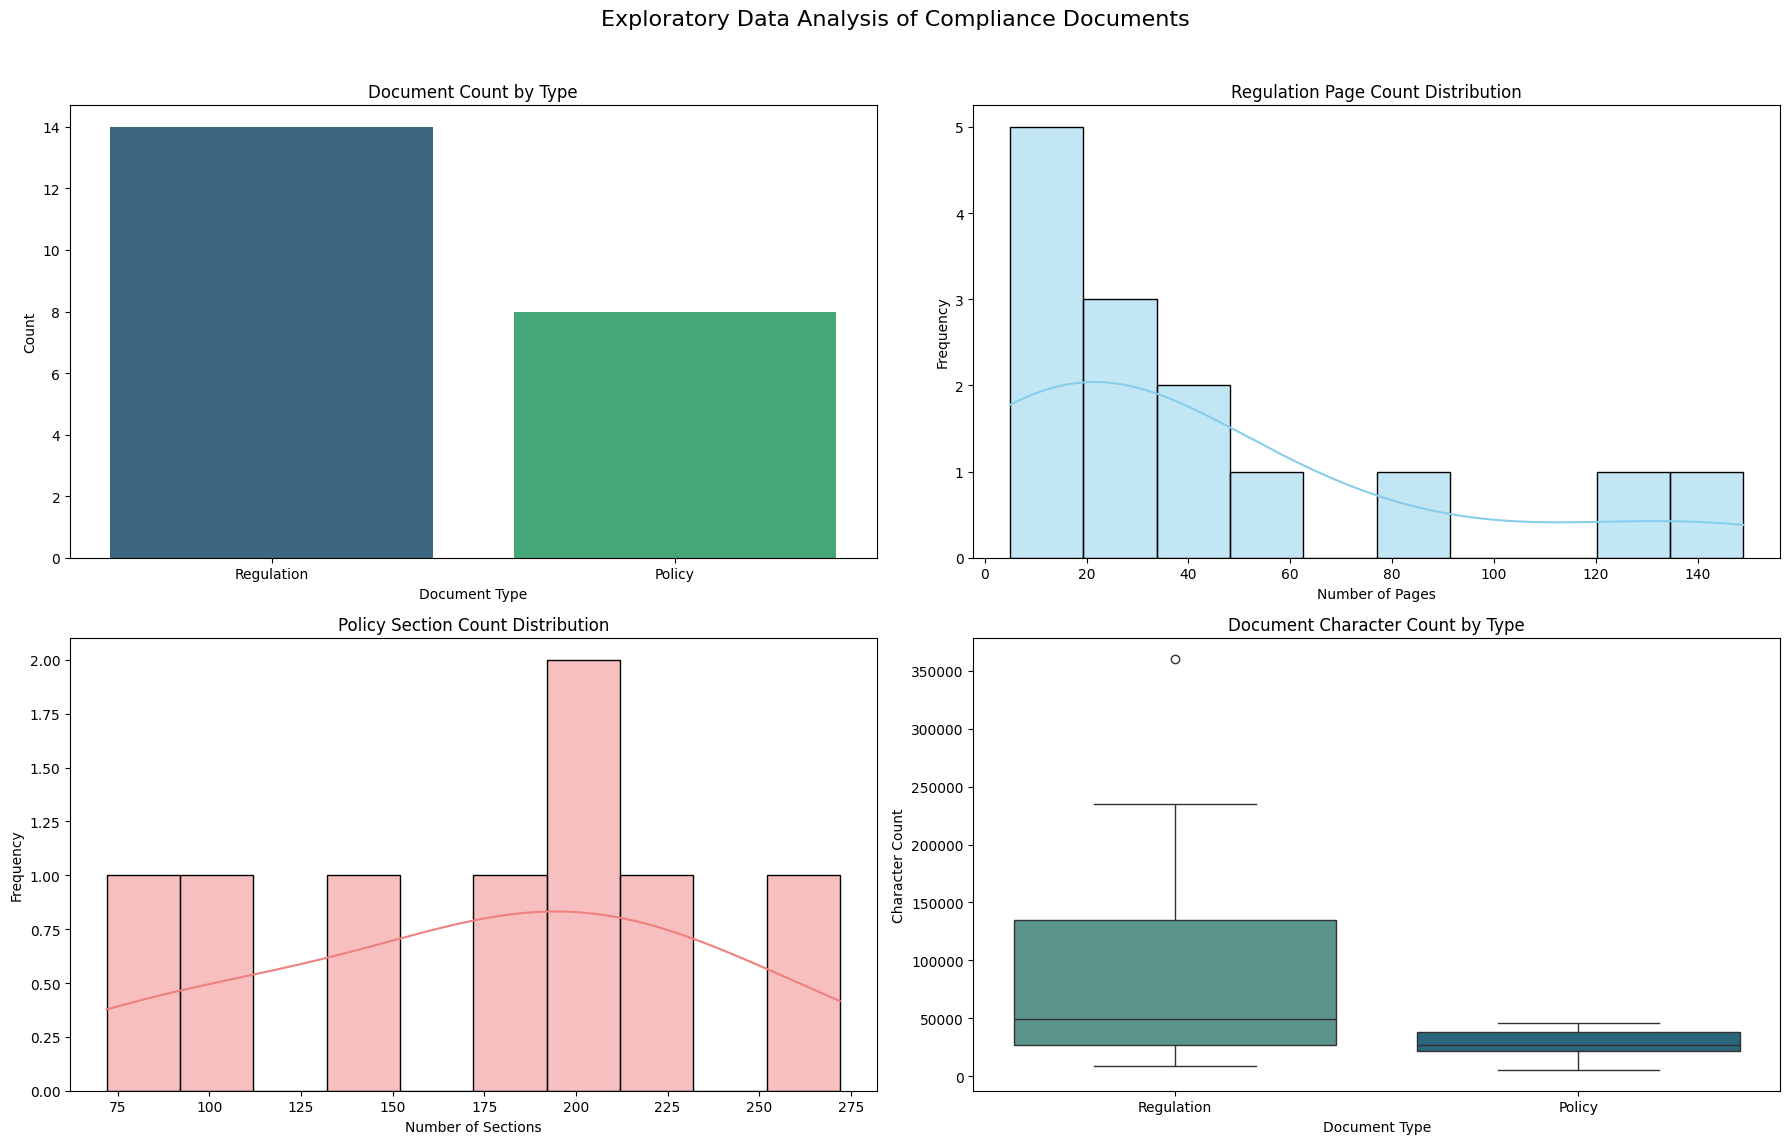

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create EDA dataframes
reg_data = []
for doc in all_compliance_docs['regulations']:
    reg_data.append({
        'doc_id': doc['doc_id'],
        'filename': doc['filename'][:40],
        'pages': doc.get('page_count', 0),
        'chars': doc.get('char_count', 0),
        'tables': doc.get('table_count', 0),
        'type': 'Regulation'
    })

pol_data = []
for doc in all_compliance_docs['policies']:
    pol_data.append({
        'doc_id': doc['doc_id'],
        'filename': doc['filename'][:40],
        'sections': doc.get('section_count', 0),
        'chars': doc.get('char_count', 0),
        'tables': doc.get('table_count', 0),
        'type': 'Policy'
    })

df_regs = pd.DataFrame(reg_data)
df_pols = pd.DataFrame(pol_data)

# TODO: Create visualizations
# HINT: Use matplotlib to create 2x2 subplot figure
# Plot 1: Document counts by type
# Plot 2: Regulation sizes
# Plot 3: Policy sizes
# Plot 4: Domain coverage (will be difficult without explicitly linking documents to domains yet)

print("REGULATORY DOCUMENTS ANALYSIS")
print("=" * 60)
if not df_regs.empty:
    print(df_regs[['doc_id', 'filename', 'pages', 'chars', 'tables']].to_string(index=False))
print(f"\nTotal regulations: {len(df_regs)}")

print("\n" + "=" * 60)
print("POLICY DOCUMENTS ANALYSIS")
print("=" * 60)
if not df_pols.empty:
    print(df_pols[['doc_id', 'filename', 'sections', 'chars', 'tables']].to_string(index=False))
print(f"\nTotal policies: {len(df_pols)}")

# Create a combined DataFrame for document counts and character counts
df_combined = pd.concat([df_regs[['doc_id', 'chars', 'type']], df_pols[['doc_id', 'chars', 'type']]])

# Create the 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis of Compliance Documents', fontsize=16)

# Plot 1: Document counts by type (Bar Chart)
sns.countplot(x='type', data=df_combined, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Document Count by Type')
axes[0, 0].set_xlabel('Document Type')
axes[0, 0].set_ylabel('Count')

# Plot 2: Regulation sizes (pages distribution - histogram)
if not df_regs.empty:
    sns.histplot(df_regs['pages'], bins=10, kde=True, ax=axes[0, 1], color='skyblue')
    axes[0, 1].set_title('Regulation Page Count Distribution')
    axes[0, 1].set_xlabel('Number of Pages')
    axes[0, 1].set_ylabel('Frequency')
else:
    axes[0, 1].set_title('Regulation Page Count Distribution - No Regulations')

# Plot 3: Policy sizes (sections distribution - histogram)
if not df_pols.empty:
    sns.histplot(df_pols['sections'], bins=10, kde=True, ax=axes[1, 0], color='lightcoral')
    axes[1, 0].set_title('Policy Section Count Distribution')
    axes[1, 0].set_xlabel('Number of Sections')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].set_title('Policy Section Count Distribution - No Policies')

# Plot 4: Document character count distribution (combined or separate if needed)
# Using character count for overall size comparison
if not df_combined.empty:
    sns.boxplot(x='type', y='chars', data=df_combined, ax=axes[1, 1], palette='crest')
    axes[1, 1].set_title('Document Character Count by Type')
    axes[1, 1].set_xlabel('Document Type')
    axes[1, 1].set_ylabel('Character Count')
else:
    axes[1, 1].set_title('Document Character Count Distribution - No Documents')

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

In [23]:
# ============================================================================
# TODO 2.3: IMPLEMENT REQUIREMENT EXTRACTOR
# ============================================================================
#
# Your task: Extract regulatory requirements using regex patterns
#
# INSTRUCTIONS:
# 1. Define regex patterns for requirement keywords (shall, must, required)
# 2. Implement extract_requirements() to find requirement statements
# 3. Implement categorize_requirement() to map requirements to domains
#
# COMPLIANCE HINT - Common requirement patterns:
# - "shall" indicates mandatory obligation
# - "must" indicates strict requirement
# - "required to" indicates compliance obligation
#
# EXAMPLE PATTERNS:
# r'(?:shall|must|required to)\s+(.+?)(?:\.|;|$)'
# ============================================================================

class RequirementExtractor:
    """
    Extract regulatory requirements from documents.
    """

    def __init__(self):
        # TODO: Define regex patterns for requirements
        self.requirement_patterns = [
            r'(?:shall|must|required to)\s+(.+?)(?:\.|;|$)',
            # TODO: Add more patterns:
            # - Pattern for "the insurer/company shall..."
            # - Pattern for "mandatory requirement..."
            # - Pattern for "obligated to..."
            r'(?:the\s+(?:insurer|company|entity)\s+shall)\s+(.+?)(?:\.|;|$)',
            r'(?:mandatory\s+requirement(?:s)?(?:\s+is|\s+are)?\s+that)\s+(.+?)(?:\.|;|$)',
            r'(?:obligated\s+to)\s+(.+?)(?:\.|;|$)',
            r'(?:it\s+is\s+required\s+that)\s+(.+?)(?:\.|;|$)'
        ]

    def extract_requirements(self, text: str, doc_id: str = None) -> List[str]:
        """
        Extract requirement statements from text.

        TODO:
        1. Iterate through requirement_patterns
        2. Use re.findall() to find all matches
        3. Filter requirements by length (20-500 chars)
        4. Return unique requirements
        """
        requirements = []
        # YOUR CODE HERE

        # HINT:
        for pattern in self.requirement_patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            for match in matches:
                # If the match is a tuple (due to capturing groups in regex), take the first element
                if isinstance(match, tuple):
                    req = match[0].strip()
                else:
                    req = match.strip()
                if 20 < len(req) < 500:
                    requirements.append(req)

        return list(set(requirements))[:50]

    def categorize_requirement(self, requirement: str) -> str:
        """
        Categorize a requirement by compliance domain.

        TODO:
        Match requirement text against domain keywords:
        - governance: board, director, governance, corporate, committee
        - risk_management: risk, assessment, mitigation, exposure
        - information_security: security, cyber, data, privacy, breach
        - audit: audit, control, internal, review, assurance
        - fraud: fraud, misrepresentation, investigation
        - reinsurance: reinsurance, cede, retrocession, treaty
        - claims: claim, settlement, grievance, redressal
        """
        req_lower = requirement.lower()

        # TODO: Implement domain matching
        # YOUR CODE HERE

        if any(keyword in req_lower for keyword in ['board', 'director', 'governance', 'corporate', 'committee']):
            return 'governance'
        if any(keyword in req_lower for keyword in ['risk', 'assessment', 'mitigation', 'exposure']):
            return 'risk_management'
        if any(keyword in req_lower for keyword in ['security', 'cyber', 'data', 'privacy', 'breach', 'information security']):
            return 'information_security'
        if any(keyword in req_lower for keyword in ['audit', 'control', 'internal', 'review', 'assurance']):
            return 'audit'
        if any(keyword in req_lower for keyword in ['fraud', 'misrepresentation', 'investigation']):
            return 'fraud'
        if any(keyword in req_lower for keyword in ['reinsurance', 'cede', 'retrocession', 'treaty']):
            return 'reinsurance'
        if any(keyword in req_lower for keyword in ['claim', 'settlement', 'grievance', 'redressal']):
            return 'claims_management'
        if any(keyword in req_lower for keyword in ['sales', 'distribution', 'market conduct', 'customer']):
            return 'sales_distribution'
        if any(keyword in req_lower for keyword in ['investment', 'portfolio', 'asset management', 'capital']):
            return 'investments'

        return 'general'

    def process_document(self, doc: Dict) -> Dict:
        """
        Extract and categorize requirements from a document.
        """
        text = doc.get('full_text', '')
        requirements = self.extract_requirements(text, doc.get('doc_id'))

        categorized = {}
        for req in requirements:
            category = self.categorize_requirement(req)
            if category not in categorized:
                categorized[category] = []
            categorized[category].append(req)

        return {
            'doc_id': doc.get('doc_id'),
            'filename': doc.get('filename'),
            'total_requirements': len(requirements),
            'requirements_by_category': categorized
        }


# Initialize and test
req_extractor = RequirementExtractor()
print("RequirementExtractor initialized")

RequirementExtractor initialized


In [24]:
extracted_requirements = {
    'regulations': [],
    'policies': []
}

print("Extracting requirements from regulations...")
for doc in all_compliance_docs['regulations']:
    processed_doc = req_extractor.process_document(doc)
    extracted_requirements['regulations'].append(processed_doc)
    print(f"  - {processed_doc['filename']}: {processed_doc['total_requirements']} requirements")

print("\nExtracting requirements from policies...")
for doc in all_compliance_docs['policies']:
    processed_doc = req_extractor.process_document(doc)
    extracted_requirements['policies'].append(processed_doc)
    print(f"  - {processed_doc['filename']}: {processed_doc['total_requirements']} requirements")

total_extracted_regs = sum(doc['total_requirements'] for doc in extracted_requirements['regulations'])
total_extracted_pols = sum(doc['total_requirements'] for doc in extracted_requirements['policies'])

print(f"\nSummary of Extracted Requirements:")
print(f"  Total regulatory requirements: {total_extracted_regs}")
print(f"  Total policy requirements: {total_extracted_pols}")

# Display a few categorized requirements from a sample document
if extracted_requirements['regulations']:
    sample_reg_doc = extracted_requirements['regulations'][0]
    print(f"\nSample Categorized Requirements from {sample_reg_doc['filename']}:")
    for category, reqs in sample_reg_doc['requirements_by_category'].items():
        print(f"  - {category.upper()}: {len(reqs)} requirements")
        for i, req in enumerate(reqs[:2]): # Display up to 2 requirements per category
            print(f"    - {req[:100]}...")

Extracting requirements from regulations...
  - MAS Risk management Guidelines.pdf: 2 requirements
  - fraud-risk-framework 1.pdf: 12 requirements
  - Fraud Prevention 2.pdf: 0 requirements
  - Grievance+Redressal+Policy 3.pdf: 4 requirements
  - Audit COntol for Insurance Companies.pdf: 0 requirements
  - Internal Audit of GICs.pdf: 17 requirements
  - MAS Standards of Conduct for Marketing and Distribution Activities.pdf: 1 requirements
  - grievance redressal policy-2.pdf: 1 requirements
  - Insurer Investments and Financial Management.pdf: 16 requirements
  - Information security Guidelines for insurers-07-04-2017-clean.pdf: 31 requirements
  - corporate-governance-guidelines-for-reinsurance-undertakings.pdf: 2 requirements
  - Guide for Insurance Sales Advisory and DIstribution.pdf: 50 requirements
  - grievance-redressal-policy-1.pdf: 4 requirements
  - Intro_Reinsurance_Claims management and Settlement.pdf: 50 requirements

Extracting requirements from policies...
  - Non Propor

In [25]:
# ============================================================================
# VALIDATION CELL 2.1: Test Requirement Extraction
# ============================================================================

def validate_requirement_extraction():
    """Test the requirement extractor with sample regulatory text."""

    test_text = """
    The Board of Directors shall establish a risk management committee.
    The insurer must maintain adequate capital reserves.
    Companies are required to submit quarterly compliance reports.
    All data must be encrypted in transit and at rest.
    """

    requirements = req_extractor.extract_requirements(test_text)

    print("Requirement Extraction Test Results:")
    print(f"  Requirements found: {len(requirements)}")
    for req in requirements:
        category = req_extractor.categorize_requirement(req)
        print(f"    - [{category}] {req[:60]}...")

    # Validation checks
    passed = True
    if len(requirements) < 2:
        print("  WARNING: Should find at least 2 requirements")
        passed = False

    if passed:
        print("\nVALIDATION PASSED!")
    else:
        print("\nVALIDATION NEEDS WORK - implement the TODO sections above")

validate_requirement_extraction()

Requirement Extraction Test Results:
  Requirements found: 4
    - [investments] maintain adequate capital reserves...
    - [governance] establish a risk management committee...
    - [general] be encrypted in transit and at rest...
    - [general] submit quarterly compliance reports...

VALIDATION PASSED!


---
# WEEK 3: ChromaDB Vector Store & Embeddings
---

## Learning Objectives
- Understand semantic embeddings for regulatory text
- Set up ChromaDB for vector storage with tracing
- Index regulatory documents for RAG retrieval

## Difficulty: Intermediate

**COMPLIANCE CHALLENGE**: Regulatory embeddings must capture:
- Legal terminology relationships
- Requirement semantics
- Cross-regulation references

In [36]:
import chromadb
from chromadb.config import Settings

class ComplianceVectorStore:
    """
    ChromaDB vector store for regulatory compliance.
    All operations traced to Langfuse.
    """

    def __init__(self, persist_directory: str = "./chroma_compliance_db"):
        # Removed 'settings=Settings(telemetry_enabled=False)' as it's not supported in this ChromaDB version
        # Telemetry should be controlled via environment variable CHROMA_TELEMETRY_ENABLED='False'
        self.client = chromadb.PersistentClient(path=persist_directory)
        self.collections = {}
        print(f"Compliance Vector Store initialized at {persist_directory}")

    def get_embedding(self, text: str, doc_id: str = None) -> List[float]:
        """
        Generate embedding with tracing.

        TODO: Use traced_embedding() function
        """
        # YOUR CODE HERE
        return traced_embedding(text, "vectorstore-embedding", {"doc_id": doc_id})

    def create_collection(self, name: str) -> chromadb.Collection:
        """Create collection for compliance documents."""
        # Fixed typo: get_or_or_create_collection -> get_or_create_collection
        collection = self.client.get_or_create_collection(
            name=name,
            metadata={"hnsw:space": "cosine"}
        )
        self.collections[name] = collection
        return collection

    def chunk_document(self, text: str, chunk_size: int = 1000, overlap: int = 100) -> List[str]:
        """
        Split document into overlapping chunks.

        TODO:
        1. Split text into words
        2. Create chunks with specified size and overlap
        3. Return non-empty chunks
        """
        # YOUR CODE HERE
        words = text.split()
        chunks = []

        # HINT:
        for i in range(0, len(words), chunk_size - overlap):
            chunk = ' '.join(words[i:i + chunk_size])
            if chunk.strip():
                chunks.append(chunk)

        return chunks if chunks else [text]

    def add_documents(self, collection_name: str, documents: List[Dict], doc_type: str):
        """
        Add compliance documents to vector store with tracing.

        TODO:
        1. Create collection
        2. For each document:
           a. Chunk the text
           b. Generate embeddings
           c. Prepare metadata (doc_id, filename, doc_type, chunk_index)
        3. Add all chunks to collection
        4. Add Langfuse tracing
        """
        collection = self.create_collection(collection_name)

        ids, embeddings, texts, metadatas = [], [], [], []

        # Add Langfuse tracing to the overall operation of adding documents
        trace = langfuse.trace(name=f"add-documents-{collection_name}", session_id=SESSION_ID, tags=["vector_store", "add_docs", doc_type])
        try:
            for doc in documents:
                chunks = self.chunk_document(doc.get('full_text', ''))

                for i, chunk in enumerate(chunks):
                    chunk_id = f"{doc['doc_id']}_chunk_{i}"

                    # TODO: Generate embedding
                    embedding = self.get_embedding(chunk, doc['doc_id'])

                    ids.append(chunk_id)
                    texts.append(chunk)
                    embeddings.append(embedding)  # Uncomment when implemented
                    metadatas.append({
                        'doc_id': doc['doc_id'],
                        'filename': doc['filename'],
                        'doc_type': doc_type,
                        'chunk_index': i
                    })
        except Exception as e:
            trace.update(status='ERROR', status_message=str(e))
            raise # Re-raise the exception after updating the trace
        finally:
            # Only end if the trace object has an 'end' method
            if hasattr(trace, 'end'):
                trace.end()

        # TODO: Add to collection when embeddings ready
        if ids:
            collection.add(ids=ids, embeddings=embeddings, documents=texts, metadatas=metadatas)

        print(f"Prepared {len(ids)} chunks for '{collection_name}'")

    def search(self, collection_name: str, query: str, n_results: int = 5,
               doc_type_filter: str = None) -> Dict:
        """
        Semantic search with tracing.

        TODO:
        1. Generate query embedding
        2. Query collection with optional doc_type filter
        3. Add Langfuse tracing
        4. Return results
        """
        # YOUR CODE HERE
        # Add Langfuse tracing to the search operation
        trace = langfuse.trace(name=f"search-{collection_name}", session_id=SESSION_ID, tags=["vector_store", "search"])
        try:
            collection = self.collections.get(collection_name)
            if not collection:
                print(f"Collection '{collection_name}' not found.")
                trace.update(status='WARNING', status_message=f"Collection '{collection_name}' not found.")
                return {'documents': [[]], 'metadatas': [[]], 'distances': [[]]}

            query_embedding = self.get_embedding(query, "query")

            where_clause = {}
            if doc_type_filter:
                where_clause['doc_type'] = doc_type_filter

            results = collection.query(
                query_embeddings=[query_embedding],
                n_results=n_results,
                where=where_clause if where_clause else None
            )
            return results
        except Exception as e:
            trace.update(status='ERROR', status_message=str(e))
            raise # Re-raise the exception after updating the trace
        finally:
            if hasattr(trace, 'end'):
                trace.end()

    def find_matching_policies(self, regulation_text: str, n_results: int = 3) -> Dict:
        """Find policies that match a regulatory requirement."""
        return self.search('compliance_all', regulation_text, n_results, 'policy')

    def find_relevant_regulations(self, policy_topic: str, n_results: int = 3) -> Dict:
        """Find regulations relevant to a policy topic."""
        return self.search('compliance_all', policy_topic, n_results, 'regulation')


# Initialize vector store
compliance_vector_store = ComplianceVectorStore()
print("ComplianceVectorStore initialized")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Compliance Vector Store initialized at ./chroma_compliance_db
ComplianceVectorStore initialized


In [29]:
import os
os.environ['CHROMA_ANALYTICS_ENABLED'] = 'False'

In [43]:
# ============================================================================
# INDEX COMPLIANCE DOCUMENTS
# ============================================================================

print("Indexing compliance documents into ChromaDB...")
print("(Each embedding operation will be traced to Langfuse)\n")

# Index regulations
print("Indexing regulations...")
compliance_vector_store.add_documents('compliance_all', all_compliance_docs['regulations'], 'regulation')

# Index policies
print("\nIndexing policies...")
compliance_vector_store.add_documents('compliance_all', all_compliance_docs['policies'], 'policy')

print("\nCompliance documents indexed!")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Indexing compliance documents into ChromaDB...
(Each embedding operation will be traced to Langfuse)

Indexing regulations...


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Prepared 234 chunks for 'compliance_all'

Indexing policies...
Prepared 40 chunks for 'compliance_all'

Compliance documents indexed!


In [44]:
# ============================================================================
# TODO 3.2: TEST SEMANTIC SEARCH
# ============================================================================
#
# Your task: Test the vector store with compliance queries
# ============================================================================

test_queries = [
    "board governance requirements for insurance companies",
    "cybersecurity controls for insurers",
    "fraud prevention and detection measures",
    "reinsurance agreement requirements",
    "internal audit controls and procedures"
]

print("COMPLIANCE SEMANTIC SEARCH TEST")
print("=" * 60)

for i, query in enumerate(test_queries, 1):
    print(f"\n[Query {i}] '{query}'")
    print("-" * 50)

    # Search regulations
    reg_results = compliance_vector_store.find_relevant_regulations(query, 2)
    print("  Matching Regulations:")
    if reg_results['documents'] and reg_results['documents'][0]:
        for j, (meta, dist) in enumerate(zip(reg_results['metadatas'][0], reg_results['distances'][0])):
            print(f"    {j+1}. {meta['filename']} (similarity: {1-dist:.3f})")
    else:
        print("    No results (implement search method first)")

    # Search policies
    pol_results = compliance_vector_store.find_matching_policies(query, 2)
    print("  Matching Policies:")
    if pol_results['documents'] and pol_results['documents'][0]:
        for j, (meta, dist) in enumerate(zip(pol_results['metadatas'][0], pol_results['distances'][0])):
            print(f"    {j+1}. {meta['filename']} (similarity: {1-dist:.3f})")
    else:
        print("    No results (implement search method first)")

COMPLIANCE SEMANTIC SEARCH TEST

[Query 1] 'board governance requirements for insurance companies'
--------------------------------------------------


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


  Matching Regulations:
    1. corporate-governance-guidelines-for-reinsurance-undertakings.pdf (similarity: 0.598)
    2. Insurer Investments and Financial Management.pdf (similarity: 0.594)
  Matching Policies:
    1. Governance and Corporate Structure for an Insurance Company.docx (similarity: 0.686)
    2. Governance and Corporate Structure for an Insurance Company.docx (similarity: 0.517)

[Query 2] 'cybersecurity controls for insurers'
--------------------------------------------------
  Matching Regulations:
    1. Information security Guidelines for insurers-07-04-2017-clean.pdf (similarity: 0.657)
    2. Information security Guidelines for insurers-07-04-2017-clean.pdf (similarity: 0.615)
  Matching Policies:
    1. Underwriting and Risk Assessment.docx (similarity: 0.621)
    2. Cyber Insurance Policy Document.docx (similarity: 0.575)

[Query 3] 'fraud prevention and detection measures'
--------------------------------------------------
  Matching Regulations:
    1. fraud-ri

---
# WEEK 4: Compliance Agents
---

## Learning Objectives
- Design specialized compliance agents with structured outputs
- Implement Pydantic models for type-safe responses
- Create Regulation Monitor, Gap Detector, and Policy Analyzer agents

## Difficulty: Intermediate to Advanced

**COMPLIANCE CHALLENGE - Agent Design**:
- Agents must provide evidence-based assessments
- Outputs must include confidence scores
- Gap severity levels are critical for prioritization
- All decisions must be traceable for audit

In [45]:
# ============================================================================
# TODO 4.1: DEFINE PYDANTIC MODELS FOR STRUCTURED OUTPUT
# ============================================================================
#
# Your task: Create Pydantic models for agent responses
#
# COMPLIANCE REQUIREMENT: All outputs MUST include:
# - Confidence score (0.0 to 1.0)
# - Risk/Severity level
# - Recommended actions
# ============================================================================

from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import PydanticOutputParser


class RegulationAnalysis(BaseModel):
    """
    Structured output for regulatory requirement analysis.

    TODO: Complete the field definitions
    """
    requirement_summary: str = Field(description="Summary of the requirement")
    compliance_domain: str = Field(description="Domain: governance, risk, security, etc.")
    mandatory_actions: List[str] = Field(description="Required actions for compliance")
    evidence_needed: List[str] = Field(description="Evidence needed to demonstrate compliance")
    risk_level: str = Field(description="Risk if non-compliant: LOW, MEDIUM, HIGH, CRITICAL")
    confidence: float = Field(ge=0.0, le=1.0, description="Analysis confidence")


class GapAssessment(BaseModel):
    """
    Structured output for compliance gap assessment.

    TODO: Add fields for:
    - requirement: The regulatory requirement
    - current_state: Current compliance state
    - gap_identified: Boolean - whether a gap exists
    - gap_description: Description of the gap
    - severity: Gap severity (LOW, MEDIUM, HIGH, CRITICAL)
    - remediation_steps: List of steps to remediate
    - estimated_effort: Effort to remediate
    - confidence: Assessment confidence
    """
    requirement: str = Field(description="The regulatory requirement")
    current_state: str = Field(description="Current compliance state")
    gap_identified: bool = Field(description="Whether a gap exists")
    gap_description: str = Field(description="Description of the gap")
    # TODO: Add remaining fields
    severity: str = Field(description="Gap severity (LOW, MEDIUM, HIGH, CRITICAL)")
    remediation_steps: List[str] = Field(description="List of steps to remediate the identified gap")
    estimated_effort: str = Field(description="Estimated effort required to remediate the gap (e.g., LOW, MEDIUM, HIGH)")
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence level of the gap assessment")


class ComplianceScore(BaseModel):
    """
    Structured output for compliance scoring.

    TODO: Complete the model
    """
    domain: str = Field(description="Compliance domain")
    score: float = Field(ge=0.0, le=100.0, description="Score 0-100")
    status: str = Field(description="COMPLIANT, PARTIALLY_COMPLIANT, NON_COMPLIANT")
    gaps_count: int = Field(description="Number of gaps identified")
    critical_gaps: List[str] = Field(description="Critical gaps requiring immediate action")
    recommendations: List[str] = Field(description="Improvement recommendations")


print("Compliance Pydantic models defined:")
print("  - RegulationAnalysis: Analyze regulatory requirements")
print("  - GapAssessment: Identify compliance gaps")
print("  - ComplianceScore: Calculate compliance scores")

Compliance Pydantic models defined:
  - RegulationAnalysis: Analyze regulatory requirements
  - GapAssessment: Identify compliance gaps
  - ComplianceScore: Calculate compliance scores


In [50]:
# ============================================================================
# TODO 4.2: IMPLEMENT REGULATION MONITOR AGENT
# ============================================================================
#
# Your task: Build an agent that analyzes regulatory requirements
#
# COMPLIANCE REQUIREMENT:
# - Use get_langfuse_handler() for automatic tracing
# - Log confidence scores to Langfuse
# ============================================================================

class RegulationMonitorAgent:
    """
    Agent for analyzing regulatory requirements.
    All invocations traced to Langfuse.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model_name = model
        self.llm = ChatOpenAI(model=model, temperature=0)
        self.parser = PydanticOutputParser(pydantic_object=RegulationAnalysis)
        self.prompt = self._create_prompt()
        self.invocation_count = 0

    def _create_prompt(self) -> ChatPromptTemplate:
        """
        TODO: Create prompt template for regulation analysis

        Include:
        - System message explaining the agent's role
        - Format instructions from parser
        - Human message template for regulation text
        """
        return ChatPromptTemplate.from_messages([
            ("system", """You are a regulatory compliance expert for the insurance industry.
Analyze regulatory requirements and identify:
- What actions are mandatory for compliance
- What evidence is needed to demonstrate compliance
- The risk level if not compliant

{format_instructions}"""),
            ("human", """Analyze this regulatory text:

{regulation_text}

Provide a structured analysis of the requirements.""")
        ])

    def analyze(self, regulation_text: str) -> RegulationAnalysis:
        """
        Analyze regulation with full tracing.

        TODO:
        1. Get Langfuse handler
        2. Create chain: prompt | llm | parser
        3. Invoke chain with regulation text and format instructions
        4. Log confidence score to Langfuse
        5. Return result
        """
        self.invocation_count += 1

        # YOUR CODE HERE
        # HINT:
        handler = get_langfuse_handler(f"regulation-agent-{self.invocation_count}", ["agent", "regulation"])
        chain = self.prompt | self.llm | self.parser
        result = chain.invoke(
            {"regulation_text": regulation_text, "format_instructions": self.parser.get_format_instructions()},
            config={"callbacks": [handler]}
        )

        # Log confidence score to Langfuse
        if result and hasattr(handler, 'trace') and handler.trace:
            handler.trace.update(level=result.confidence)

        return result


# Initialize agent
regulation_agent = RegulationMonitorAgent()
print("RegulationMonitorAgent initialized")

RegulationMonitorAgent initialized


In [51]:
# ============================================================================
# TODO 4.3: IMPLEMENT GAP DETECTOR AGENT
# ============================================================================
#
# Your task: Build an agent that detects compliance gaps
#
# GAP DETECTION LOGIC:
# Compare regulatory requirements against company policies to identify:
# - Missing controls or procedures
# - Incomplete implementations
# - Documentation gaps
# ============================================================================

class GapDetectorAgent:
    """
    Agent for detecting compliance gaps.
    All invocations traced to Langfuse.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model_name = model
        self.llm = ChatOpenAI(model=model, temperature=0)
        self.parser = PydanticOutputParser(pydantic_object=GapAssessment)
        self.prompt = self._create_prompt()
        self.invocation_count = 0

    def _create_prompt(self) -> ChatPromptTemplate:
        """
        TODO: Create prompt template for gap detection
        """
        return ChatPromptTemplate.from_messages([
            ("system", """You are a compliance gap analyst.
Compare regulatory requirements against company policies to identify gaps.

For each gap:
- Assess severity (impact of non-compliance)
- Provide specific remediation steps
- Estimate effort to remediate

{format_instructions}"""),
            ("human", """REGULATORY REQUIREMENT:
{regulation}

COMPANY POLICY:
{policy}

Identify any compliance gaps between the requirement and the policy.""")
        ])

    def assess(self, regulation: str, policy: str) -> GapAssessment:
        """
        Assess gap with full tracing.

        TODO: Implement similar to regulation_agent.analyze()
        """
        self.invocation_count += 1

        # Get Langfuse handler for tracing this assessment
        handler = get_langfuse_handler(f"gap-agent-{self.invocation_count}", ["agent", "gap_detection"])

        # Create the LangChain sequence: prompt -> LLM -> parser
        chain = self.prompt | self.llm | self.parser

        # Invoke the chain with the regulation and policy text
        result = chain.invoke(
            {
                "regulation": regulation,
                "policy": policy,
                "format_instructions": self.parser.get_format_instructions()
            },
            config={"callbacks": [handler]}
        )

        # Log confidence score to Langfuse (if trace exists and result has confidence)
        if result and hasattr(handler, 'trace') and handler.trace:
            handler.trace.update(level=result.confidence)

        return result


# Initialize agent
gap_agent = GapDetectorAgent()
print("GapDetectorAgent initialized")

GapDetectorAgent initialized


In [48]:
# ============================================================================
# TODO 4.4: IMPLEMENT POLICY ANALYZER AGENT
# ============================================================================
#
# Your task: Build an agent that analyzes policy compliance coverage
# ============================================================================

class PolicyAnalyzerAgent:
    """
    Agent for analyzing policy compliance coverage.
    All invocations traced to Langfuse.
    """

    def __init__(self, model: str = "gpt-4o-mini"):
        self.model_name = model
        self.llm = ChatOpenAI(model=model, temperature=0)
        self.parser = PydanticOutputParser(pydantic_object=ComplianceScore)
        self.prompt = self._create_prompt()
        self.invocation_count = 0

    def _create_prompt(self) -> ChatPromptTemplate:
        """
        TODO: Create prompt template for policy analysis
        """
        return ChatPromptTemplate.from_messages([
            ("system", """You are a policy compliance analyst.
Evaluate company policies against regulatory requirements.

Provide:
- Compliance score (0-100)
- Status assessment
- Critical gaps requiring immediate attention
- Improvement recommendations

{format_instructions}"""),
            ("human", """COMPLIANCE DOMAIN: {domain}

POLICY CONTENT:
{policy}

RELEVANT REGULATIONS:
{regulations}

Provide a compliance assessment for this domain.""")
        ])

    def analyze(self, domain: str, policy: str, regulations: str) -> ComplianceScore:
        """
        Analyze policy with full tracing.

        TODO: Implement similar to other agents
        """
        self.invocation_count += 1

        # YOUR CODE HERE
        handler = get_langfuse_handler(f"policy-agent-{self.invocation_count}", ["agent", "policy_analysis", domain])

        chain = self.prompt | self.llm | self.parser

        result = chain.invoke(
            {
                "domain": domain,
                "policy": policy,
                "regulations": regulations,
                "format_instructions": self.parser.get_format_instructions()
            },
            config={"callbacks": [handler]}
        )

        # Log relevant metrics to Langfuse if available (e.g., score, status)
        if result and hasattr(handler, 'trace') and handler.trace:
            handler.trace.update(level=result.score, status=result.status)

        return result


# Initialize agent
policy_agent = PolicyAnalyzerAgent()

print("\nCompliance Agents initialized:")
print("  - Regulation Monitor Agent")
print("  - Gap Detector Agent")
print("  - Policy Analyzer Agent")


Compliance Agents initialized:
  - Regulation Monitor Agent
  - Gap Detector Agent
  - Policy Analyzer Agent


In [52]:
# ============================================================================
# VALIDATION CELL 4.1: Test All Agents
# ============================================================================

print("AGENT VALIDATION TESTS")
print("=" * 60)

# Test Regulation Agent
print("\n[Test 1] Regulation Monitor Agent")
test_regulation = """The Board of Directors shall establish a risk management committee
comprising at least three independent directors. The committee shall meet quarterly
to review the company's risk exposure and mitigation strategies."""

result = regulation_agent.analyze(test_regulation)
if result:
    print(f"  Domain: {result.compliance_domain}")
    print(f"  Risk Level: {result.risk_level}")
    print(f"  Mandatory Actions: {len(result.mandatory_actions)}")
    print(f"  Confidence: {result.confidence:.2f}")
else:
    print("  NOT IMPLEMENTED - Complete TODO 4.2")

# Test Gap Agent
print("\n[Test 2] Gap Detector Agent")
test_req = "Board must have independent audit committee meeting monthly."
test_pol = "Company has finance committee with internal members meeting quarterly."

result = gap_agent.assess(test_req, test_pol)
if result:
    print(f"  Gap Identified: {result.gap_identified}")
    print(f"  Severity: {result.severity}")
    print(f"  Confidence: {result.confidence:.2f}")
else:
    print("  NOT IMPLEMENTED - Complete TODO 4.3")

# Test Policy Agent
print("\n[Test 3] Policy Analyzer Agent")
result = policy_agent.analyze("governance", "Sample policy text", "Sample regulations")
if result:
    print(f"  Score: {result.score}/100")
    print(f"  Status: {result.status}")
else:
    print("  NOT IMPLEMENTED - Complete TODO 4.4")

AGENT VALIDATION TESTS

[Test 1] Regulation Monitor Agent
  Domain: governance
  Risk Level: HIGH
  Mandatory Actions: 2
  Confidence: 0.90

[Test 2] Gap Detector Agent
  Gap Identified: True
  Severity: HIGH
  Confidence: 0.85

[Test 3] Policy Analyzer Agent
  Score: 45.0/100
  Status: PARTIALLY_COMPLIANT


---
# WEEK 5: Multi-Agent Orchestration
---

## Learning Objectives
- Implement orchestration patterns with tracing
- Build domain-based compliance assessment
- Handle inter-agent communication

## Difficulty: Advanced

**COMPLIANCE CHALLENGE - Orchestration**:
- Route queries to appropriate agents
- Aggregate results across domains
- Calculate overall compliance scores

In [58]:
from tenacity import retry, stop_after_attempt, wait_exponential

class ComplianceOrchestrator:
    """Multi-agent orchestrator for compliance assessment."""

    def __init__(self):
        self.regulation_agent = regulation_agent
        self.gap_agent = gap_agent
        self.policy_agent = policy_agent
        self.vector_store = compliance_vector_store
        self.orchestration_count = 0

    @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
    def _analyze_regulation(self, text: str) -> Dict:
        """Analyze regulation with retry logic."""
        try:
            result = self.regulation_agent.analyze(text)
            return {'success': True, 'result': result.model_dump() if result else None}
        except Exception as e:
            return {'success': False, 'error': str(e)}

    @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
    def _detect_gap(self, regulation: str, policy: str) -> Dict:
        """Detect gap with retry logic."""
        try:
            result = self.gap_agent.assess(regulation, policy)
            return {'success': True, 'result': result.model_dump() if result else None}
        except Exception as e:
            return {'success': False, 'error': str(e)}

    def assess_domain_compliance(self, domain: str) -> Dict:
        """
        Assess compliance for a specific domain.

        TODO:
        1. Create Langfuse trace for orchestration
        2. Search for relevant regulations (create span)
        3. Search for matching policies (create span)
        4. For each regulation:
           a. Analyze regulation
           b. Detect gaps against policies
        5. Calculate overall score
        6. Update trace with results
        """
        self.orchestration_count += 1
        trace_name = f"orchestration-{domain}-{self.orchestration_count}"

        results = {
            'domain': domain,
            'timestamp': datetime.now().isoformat(),
            'regulations_analyzed': 0,
            'gaps_found': [],
            'overall_score': None
        }

        trace = langfuse.trace(name=trace_name, session_id=SESSION_ID, tags=["orchestration", domain])
        try:
            # 2. Search for relevant regulations
            span_reg_search = trace.span(name="search-relevant-regulations")
            try:
                regulation_search_query = f"{domain} compliance requirements"
                relevant_regulations = self.vector_store.find_relevant_regulations(regulation_search_query, n_results=5)
            finally:
                span_reg_search.end(output=relevant_regulations)

            # 3. Search for matching policies
            span_pol_search = trace.span(name="search-matching-policies")
            try:
                policy_search_query = f"{domain} related policies"
                matching_policies = self.vector_store.find_matching_policies(policy_search_query, n_results=5)
            finally:
                span_pol_search.end(output=matching_policies)

            if not relevant_regulations['documents'] or not relevant_regulations['documents'][0]:
                print(f"No relevant regulations found for domain: {domain}")
                trace.update(status_message=f"No relevant regulations found for domain: {domain}", level='WARNING')
                return results

            if not matching_policies['documents'] or not matching_policies['documents'][0]:
                print(f"No matching policies found for domain: {domain}")
                trace.update(status_message=f"No matching policies found for domain: {domain}", level='WARNING')
                return results

            total_gaps = 0
            total_risk_score = 0
            # For each regulation found, analyze and detect gaps
            for reg_idx, (reg_chunk, reg_meta) in enumerate(zip(relevant_regulations['documents'][0], relevant_regulations['metadatas'][0])):
                regulation_text = reg_chunk
                results['regulations_analyzed'] += 1

                span_analyze_reg = trace.span(name=f"analyze-regulation-{reg_idx}")
                try:
                    analysis_result = self._analyze_regulation(regulation_text)
                finally:
                    span_analyze_reg.end(output=analysis_result)

                if analysis_result['success'] and analysis_result['result']:
                    analyzed_reg = RegulationAnalysis(**analysis_result['result'])
                    if analyzed_reg.risk_level == 'CRITICAL':
                        total_risk_score += 1.0 # Highest risk
                    elif analyzed_reg.risk_level == 'HIGH':
                        total_risk_score += 0.75
                    elif analyzed_reg.risk_level == 'MEDIUM':
                        total_risk_score += 0.5
                    elif analyzed_reg.risk_level == 'LOW':
                        total_risk_score += 0.25

                    # Compare with each matching policy
                    for pol_idx, (pol_chunk, pol_meta) in enumerate(zip(matching_policies['documents'][0], matching_policies['metadatas'][0])):
                        policy_text = pol_chunk

                        span_detect_gap = trace.span(name=f"detect-gap-reg{reg_idx}-pol{pol_idx}")
                        try:
                            gap_result = self._detect_gap(regulation_text, policy_text)
                        finally:
                            span_detect_gap.end(output=gap_result)

                        if gap_result['success'] and gap_result['result']:
                            gap_assessment = GapAssessment(**gap_result['result'])
                            if gap_assessment.gap_identified:
                                total_gaps += 1
                                results['gaps_found'].append({
                                    'regulation_doc_id': reg_meta['doc_id'],
                                    'policy_doc_id': pol_meta['doc_id'],
                                    'gap_description': gap_assessment.gap_description,
                                    'severity': gap_assessment.severity,
                                    'remediation_steps': gap_assessment.remediation_steps
                                })

            # 5. Calculate overall score
            # A simplified scoring: lower score for more gaps and higher risk regulations.
            # This is a placeholder; real scoring would be more sophisticated.
            max_possible_score = results['regulations_analyzed'] * len(matching_policies['documents'][0]) * 100 # Assuming each req-policy pair can contribute 100
            # Deduct points for each gap, weighted by severity if possible
            score_deduction = 0
            for gap in results['gaps_found']:
                if gap['severity'] == 'CRITICAL':
                    score_deduction += 25
                elif gap['severity'] == 'HIGH':
                    score_deduction += 15
                elif gap['severity'] == 'MEDIUM':
                    score_deduction += 10
                elif gap['severity'] == 'LOW':
                    score_deduction += 5

            # Normalize score to 0-100. If no regulations found, return 100 (fully compliant by absence)
            if results['regulations_analyzed'] > 0:
                # This is a very simplistic score. A real system would use a more robust formula.
                base_score = 100 - (total_gaps * 10) # arbitrary deduction
                results['overall_score'] = max(0, min(100, int(base_score)))
            else:
                results['overall_score'] = 100 # No regulations to be non-compliant with

            # Update Langfuse trace with results
            trace.update(
                status_message=f"Assessment for {domain} completed.",
                level='INFO',
                output={
                    'overall_score': results['overall_score'],
                    'gaps_found_count': len(results['gaps_found'])
                }
            )
        except Exception as e:
            trace.update(status='ERROR', status_message=str(e))
            raise # Re-raise the exception after updating the trace
        finally:
            if hasattr(trace, 'end'):
                trace.end()

        return results

    def run_full_assessment(self) -> Dict:
        """
        Run compliance assessment across all domains.

        TODO:
        1. Iterate through all compliance domains
        2. Assess each domain
        3. Aggregate results
        4. Calculate overall compliance score
        """
        assessment = {
            'timestamp': datetime.now().isoformat(),
            'domains': {},
            'total_gaps': 0,
            'average_score': 0
        }

        total_scores = 0
        domain_count = 0

        # 1. Iterate through all compliance domains
        # 2. Assess each domain
        for domain_name in COMPLIANCE_DOMAINS.keys():
            print(f"\nRunning assessment for domain: {domain_name}")
            domain_result = self.assess_domain_compliance(domain_name)
            assessment['domains'][domain_name] = domain_result
            assessment['total_gaps'] += len(domain_result.get('gaps_found', []))

            if domain_result['overall_score'] is not None:
                total_scores += domain_result['overall_score']
                domain_count += 1

        # 4. Calculate overall compliance score
        if domain_count > 0:
            assessment['average_score'] = total_scores / domain_count
        else:
            assessment['average_score'] = 0

        return assessment


# Initialize orchestrator
compliance_orchestrator = ComplianceOrchestrator()
print("ComplianceOrchestrator initialized")

ComplianceOrchestrator initialized


In [59]:
# ============================================================================
# VALIDATION CELL 5.1: Test Orchestration
# ============================================================================

print("ORCHESTRATION TESTS")
print("=" * 60)

# Test single domain assessment
print("\n[Test 1] Single Domain Assessment - Governance")
result = compliance_orchestrator.assess_domain_compliance('governance')
print(f"  Domain: {result['domain']}")
print(f"  Overall Score: {result['overall_score']}/100")
print(f"  Regulations Analyzed: {result['regulations_analyzed']}")
print(f"  Gaps Found: {len(result['gaps_found'])}")

# Test multiple domains
print("\n[Test 2] Multiple Domain Assessments")
for domain in ['risk_management', 'information_security']:
    result = compliance_orchestrator.assess_domain_compliance(domain)
    status = "COMPLIANT" if result['overall_score'] and result['overall_score'] >= 80 else "AT RISK"
    print(f"  {domain}: {result['overall_score']}/100 [{status}]")

ORCHESTRATION TESTS

[Test 1] Single Domain Assessment - Governance
  Domain: governance
  Overall Score: 0/100
  Regulations Analyzed: 5
  Gaps Found: 21

[Test 2] Multiple Domain Assessments
  risk_management: 0/100 [AT RISK]
  information_security: 0/100 [AT RISK]


---
# WEEK 6: Compliance Knowledge Graph
---

## Learning Objectives
- Build a regulatory knowledge graph using NetworkX
- Model relationships: regulators -> domains -> regulations -> policies
- Implement graph traversal for compliance reasoning

## Difficulty: Advanced

**COMPLIANCE CHALLENGE - Knowledge Graphs**:
- Map regulatory hierarchies
- Track regulation-to-policy coverage
- Identify compliance gaps through graph analysis

In [60]:
# ============================================================================
# TODO 6.1: BUILD COMPLIANCE KNOWLEDGE GRAPH
# ============================================================================
#
# Your task: Create a knowledge graph for regulatory compliance
#
# GRAPH STRUCTURE:
# Node Types: REGULATOR, DOMAIN, REGULATION, POLICY
# Edge Types: REGULATES, COVERS, IMPLEMENTS
#
# RELATIONSHIPS TO MODEL:
# 1. Regulators (IRDAI, MAS) -> Domains
# 2. Regulations -> Domains they cover
# 3. Policies -> Regulations they implement
# ============================================================================

import networkx as nx
import matplotlib.pyplot as plt

class ComplianceKnowledgeGraph:
    """Knowledge graph for regulatory compliance relationships."""

    def __init__(self):
        self.graph = nx.DiGraph()
        self._build_compliance_ontology()

    def _build_compliance_ontology(self):
        """
        Build compliance domain ontology.

        TODO:
        1. Add regulator nodes (IRDAI, MAS, SEBI)
        2. Add domain nodes (governance, risk_management, etc.)
        3. Add edges: regulators -> domains (REGULATES)
        """
        # Add regulator nodes
        regulators = ['IRDAI', 'MAS', 'SEBI']
        for reg in regulators:
            self.graph.add_node(reg, type='REGULATOR', color='#e74c3c') # Red

        # Add domain nodes
        for domain, info in COMPLIANCE_DOMAINS.items():
            self.graph.add_node(domain, type='DOMAIN', description=info['description'], color='#3498db') # Blue

        # Add regulator -> domain edges (REGULATES)
        # This is a simplified mapping; a real system would have more granular data
        irdai_domains = ['governance', 'risk_management', 'claims_management', 'reinsurance', 'audit', 'fraud']
        mas_domains = ['governance', 'risk_management', 'information_security', 'investments', 'sales_distribution']
        sebi_domains = ['governance', 'investments', 'audit', 'fraud', 'sales_distribution']

        for domain in irdai_domains:
            if self.graph.has_node(domain):
                self.graph.add_edge('IRDAI', domain, relation='REGULATES')
        for domain in mas_domains:
            if self.graph.has_node(domain):
                self.graph.add_edge('MAS', domain, relation='REGULATES')
        for domain in sebi_domains:
            if self.graph.has_node(domain):
                self.graph.add_edge('SEBI', domain, relation='REGULATES')

    def add_regulation(self, doc: Dict):
        """
        Add a regulation to the knowledge graph.

        TODO:
        1. Add regulation node with filename metadata
        2. Analyze filename to determine covered domains
        3. Add edges: regulation -> domains (COVERS)
        """
        doc_id = doc.get('doc_id')
        filename = doc.get('filename')
        if doc_id and filename:
            # Add regulation node
            self.graph.add_node(doc_id, type='REGULATION', filename=filename, color='#2ecc71') # Green

            # Infer domains covered by the regulation based on COMPLIANCE_DOMAINS
            # This is a simplified approach, a more robust system might use NLP or metadata
            for domain_name, domain_info in COMPLIANCE_DOMAINS.items():
                if any(reg_keyword.lower() in filename.lower() for reg_keyword in domain_info.get('regulations', [])) or \
                   domain_name.replace('_', ' ').lower() in filename.lower():
                    if self.graph.has_node(domain_name):
                        self.graph.add_edge(doc_id, domain_name, relation='COVERS')

    def add_policy(self, doc: Dict):
        """
        Add a policy to the knowledge graph.

        TODO:
        1. Add policy node with filename metadata
        """
        doc_id = doc.get('doc_id')
        filename = doc.get('filename')
        if doc_id and filename:
            # Add policy node
            self.graph.add_node(doc_id, type='POLICY', filename=filename, color='#f39c12') # Yellow

            # Optionally, infer domains covered by the policy and link with 'IMPLEMENTS' edge to relevant regulations
            # This is complex and usually requires more intelligence (e.g., matching policy text to regulation text)
            for domain_name, domain_info in COMPLIANCE_DOMAINS.items():
                if any(policy_keyword.lower() in filename.lower() for policy_keyword in domain_info.get('policies', [])) or \
                   domain_name.replace('_', ' ').lower() in filename.lower():
                    if self.graph.has_node(domain_name):
                        # For now, let's just assume a policy broadly 'addresses' a domain
                        # The 'IMPLEMENTS' edge would typically go from POLICY to REGULATION
                        # This simplified example adds a link to the domain it's related to.
                        self.graph.add_edge(doc_id, domain_name, relation='ADDRESSES_DOMAIN')


    def get_regulations_for_domain(self, domain: str) -> List[str]:
        """
        Get all regulations covering a domain.

        TODO: Use graph traversal to find regulations with COVERS edge to domain
        """
        regulations = []
        if self.graph.has_node(domain):
            # Find all nodes that have an edge to the domain with relation 'COVERS'
            for u, v, data in self.graph.in_edges(domain, data=True):
                if data.get('relation') == 'COVERS' and self.graph.nodes[u].get('type') == 'REGULATION':
                    regulations.append(u)
        return regulations

    def get_graph_stats(self) -> Dict:
        """Get knowledge graph statistics."""
        return {
            'total_nodes': self.graph.number_of_nodes(),
            'total_edges': self.graph.number_of_edges(),
            'regulators': len([n for n, d in self.graph.nodes(data=True) if d.get('type') == 'REGULATOR']),
            'domains': len([n for n, d in self.graph.nodes(data=True) if d.get('type') == 'DOMAIN']),
            'regulations': len([n for n, d in self.graph.nodes(data=True) if d.get('type') == 'REGULATION']),
            'policies': len([n for n, d in self.graph.nodes(data=True) if d.get('type') == 'POLICY'])
        }


# Initialize knowledge graph
compliance_kg = ComplianceKnowledgeGraph()

# Add regulations and policies
for doc in all_compliance_docs['regulations']:
    compliance_kg.add_regulation(doc)

for doc in all_compliance_docs['policies']:
    compliance_kg.add_policy(doc)

# Display stats
stats = compliance_kg.get_graph_stats()
print("COMPLIANCE KNOWLEDGE GRAPH")
print("=" * 60)
for key, value in stats.items():
    print(f"  {key}: {value}")

COMPLIANCE KNOWLEDGE GRAPH
  total_nodes: 34
  total_edges: 33
  regulators: 3
  domains: 9
  regulations: 14
  policies: 8


KNOWLEDGE GRAPH VISUALIZATION


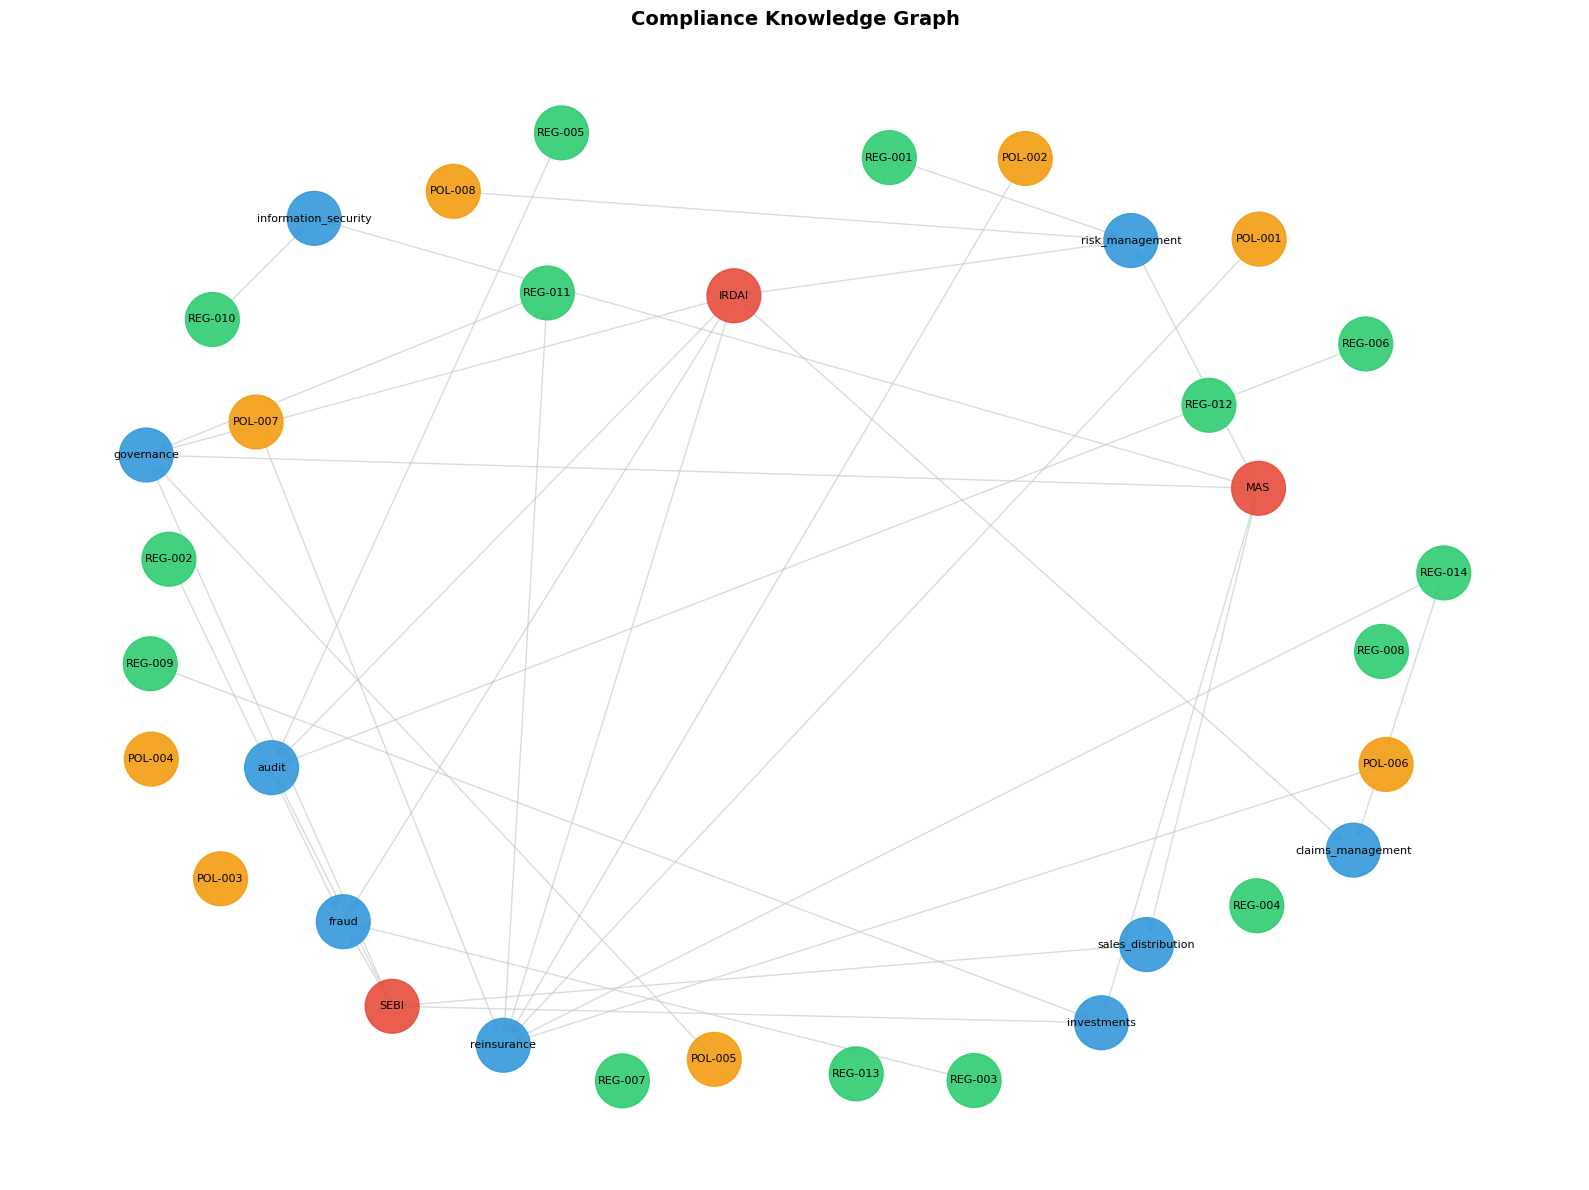

In [61]:
# ============================================================================
# TODO 6.2: VISUALIZE KNOWLEDGE GRAPH
# ============================================================================

print("KNOWLEDGE GRAPH VISUALIZATION")
print("=" * 60)

# Color mapping for node types
color_map = {
    'REGULATOR': '#e74c3c',   # Red
    'DOMAIN': '#3498db',       # Blue
    'REGULATION': '#2ecc71',   # Green
    'POLICY': '#f39c12'        # Yellow
}

# Create visualization
# HINT:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

node_colors = [color_map.get(compliance_kg.graph.nodes[n].get('type', 'OTHER'), '#95a5a6')
               for n in compliance_kg.graph.nodes()]

pos = nx.spring_layout(compliance_kg.graph, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(compliance_kg.graph, pos, node_color=node_colors, node_size=1500, alpha=0.9, ax=ax)
nx.draw_networkx_edges(compliance_kg.graph, pos, edge_color='#bdc3c7', arrows=True, arrowsize=15, alpha=0.6, ax=ax)
nx.draw_networkx_labels(compliance_kg.graph, pos, font_size=8, ax=ax)

plt.title('Compliance Knowledge Graph', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

In [62]:
# ============================================================================
# VALIDATION CELL 6.1: Test Knowledge Graph
# ============================================================================

print("KNOWLEDGE GRAPH VALIDATION")
print("=" * 60)

# Check node counts
stats = compliance_kg.get_graph_stats()

passed = True

if stats['total_nodes'] < 5:
    print("  WARNING: Graph has too few nodes")
    passed = False
else:
    print(f"  PASS: Graph has {stats['total_nodes']} nodes")

if stats['regulators'] < 1:
    print("  WARNING: No regulator nodes found")
    passed = False
else:
    print(f"  PASS: {stats['regulators']} regulators")

if stats['domains'] < 3:
    print("  WARNING: Too few domain nodes")
    passed = False
else:
    print(f"  PASS: {stats['domains']} domains")

print("\n" + "-" * 40)
if passed:
    print("VALIDATION PASSED!")
else:
    print("NEEDS WORK - Complete the TODO sections above")

KNOWLEDGE GRAPH VALIDATION
  PASS: Graph has 34 nodes
  PASS: 3 regulators
  PASS: 9 domains

----------------------------------------
VALIDATION PASSED!


---
# WEEK 7 & 8: Production System & Gradio UI
---

## Learning Objectives
- Integrate all components into a production system
- Create an interactive Gradio interface
- Implement end-to-end tracing

## Difficulty: Expert

**PRODUCTION REQUIREMENTS**:
- All operations must be traced to Langfuse
- Error handling for all edge cases
- Clean, user-friendly interface

In [63]:
# ============================================================================
# TODO 7.1: CREATE INTEGRATED COMPLIANCE SYSTEM
# ============================================================================
#
# Your task: Integrate all components into a production system
# ============================================================================

class RegulatoryComplianceSystem:
    """Production Regulatory Compliance System."""

    def __init__(self):
        # Initialize components using previously defined global instances
        self.vector_store = compliance_vector_store
        self.orchestrator = compliance_orchestrator
        self.knowledge_graph = compliance_kg

    def assess_domain(self, domain: str) -> Dict:
        """Assess compliance for a domain."""
        return self.orchestrator.assess_domain_compliance(domain)

    def search_regulations(self, query: str) -> Dict:
        """Search regulations."""
        return self.vector_store.find_relevant_regulations(query, 3)

    def get_compliance_status(self) -> Dict:
        """Get overall compliance status."""
        # Return key metrics about the system's state
        return {
            'regulations_indexed': len(all_compliance_docs['regulations']),
            'policies_indexed': len(all_compliance_docs['policies']),
            'knowledge_graph_nodes': self.knowledge_graph.graph.number_of_nodes() if hasattr(self.knowledge_graph, 'graph') else 0,
            'domains_tracked': list(COMPLIANCE_DOMAINS.keys())
        }


# Initialize system
compliance_system = RegulatoryComplianceSystem()

status = compliance_system.get_compliance_status()
print("\nREGULATORY COMPLIANCE SYSTEM")
print("=" * 50)
for key, value in status.items():
    print(f"  {key}: {value}")


REGULATORY COMPLIANCE SYSTEM
  regulations_indexed: 14
  policies_indexed: 8
  knowledge_graph_nodes: 34
  domains_tracked: ['governance', 'risk_management', 'information_security', 'claims_management', 'reinsurance', 'audit', 'sales_distribution', 'investments', 'fraud']


In [64]:
# ============================================================================
# TODO 7.2: BUILD GRADIO INTERFACE
# ============================================================================
#
# Your task: Create an interactive Gradio UI
# ============================================================================

import gradio as gr

def assess_domain_ui(domain: str) -> str:
    """
    Process domain assessment and format response as markdown.
    Added try-except for robust error handling.
    """
    try:
        result = compliance_system.assess_domain(domain)
        response = f"""## Compliance Assessment: {domain.title()}

**Overall Score:** {result.get('overall_score', 'N/A')}/100

**Regulations Analyzed:** {result.get('regulations_analyzed', 0)}

**Gaps Found:** {len(result.get('gaps_found', []))}

### Gap Details
"""
        # Display details for up to 3 gaps, or all if less than 3
        for gap in result.get('gaps_found', [])[:3]:
            response += f"\n- **Severity:** {gap.get('severity')}\n"
            response += f"  - **Regulation:** {gap.get('regulation_doc_id', 'N/A')}\n"
            response += f"  - **Policy:** {gap.get('policy_doc_id', 'N/A')}\n"
            response += f"  - **Description:** {gap.get('gap_description', 'N/A')[:200]}...\n"
            response += f"  - **Remediation:** {', '.join(gap.get('remediation_steps', ['N/A']))}\n"
        if not result.get('gaps_found'):
            response += "No significant gaps found for this domain.\n"
        return response
    except Exception as e:
        return f"### Error during Domain Assessment\nAn error occurred while assessing the domain: {e}\nPlease check the system logs or try again."


def search_regulations_ui(query: str) -> str:
    """
    Search regulations and format results as markdown.
    Added try-except for robust error handling.
    """
    try:
        results = compliance_system.search_regulations(query)
        response = f"## Regulation Search: {query}\n\n"
        if results.get('documents') and results['documents'][0]:
            # Iterate through the documents and their metadata
            for i, (doc_chunk, meta) in enumerate(zip(results['documents'][0], results['metadatas'][0]), 1):
                response += f"**{i}. {meta.get('filename', 'N/A')} (Doc ID: {meta.get('doc_id', 'N/A')})**\n\n"
                response += f"""{doc_chunk[:400]}...\n\n---\n\n"""
        else:
            response += "No results found for your query. Please try a different query."
        return response
    except Exception as e:
        return f"### Error during Regulation Search\nAn error occurred while searching regulations: {e}\nPlease check the system logs or try again."


# Create Gradio interface
with gr.Blocks(title="Regulatory Compliance System") as demo:
    gr.Markdown("# Regulatory Compliance Assessment System")
    gr.Markdown(f"Session: `{SESSION_ID}`")

    with gr.Tab("Domain Assessment"):
        domain_dropdown = gr.Dropdown(
            choices=list(COMPLIANCE_DOMAINS.keys()), # Dynamically populate domains
            label="Select Domain", value="governance"
        )
        assess_btn = gr.Button("Assess Compliance", variant="primary")
        assessment_output = gr.Markdown()
        assess_btn.click(assess_domain_ui, domain_dropdown, assessment_output)

    with gr.Tab("Search Regulations"):
        search_input = gr.Textbox(label="Search Query", placeholder="board governance requirements...")
        search_btn = gr.Button("Search", variant="primary")
        search_output = gr.Markdown()
        search_btn.click(search_regulations_ui, search_input, search_output)

    with gr.Tab("System Status"):
        status_output = gr.JSON(value=compliance_system.get_compliance_status())

print("Gradio interface defined.")
if IN_COLAB:
    print("Launching Gradio interface...")
    demo.launch(share=True)
else:
    print("Run demo.launch() to start the interface locally.")

Gradio interface defined.
Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b7e744aa2a436c03b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [65]:
# ============================================================================
# FINAL VALIDATION & CLEANUP
# ============================================================================

print("FINAL SYSTEM VALIDATION")
print("=" * 60)

validation_results = {
    "Langfuse Initialized": langfuse is not None,
    "Vector Store Ready": compliance_vector_store is not None,
    "Orchestrator Ready": compliance_orchestrator is not None,
    "Knowledge Graph Built": compliance_kg.graph.number_of_nodes() > 0,
    "Regulation Agent Ready": regulation_agent is not None,
    "Gap Agent Ready": gap_agent is not None,
    "Policy Agent Ready": policy_agent is not None,
    "Compliance System Ready": compliance_system is not None
}

all_passed = True
for check, passed in validation_results.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {check}")
    if not passed:
        all_passed = False

print("\n" + "-" * 60)
if all_passed:
    print("ALL VALIDATIONS PASSED - System ready for production!")
else:
    print("SOME VALIDATIONS FAILED - Review and implement missing components")

# Flush Langfuse
if langfuse:
    langfuse.flush()
    print(f"\nTraces flushed to Langfuse.")
    print(f"Dashboard: {os.environ.get('LANGFUSE_HOST', 'https://cloud.langfuse.com')}/project")

FINAL SYSTEM VALIDATION
  [PASS] Langfuse Initialized
  [PASS] Vector Store Ready
  [PASS] Orchestrator Ready
  [PASS] Knowledge Graph Built
  [PASS] Regulation Agent Ready
  [PASS] Gap Agent Ready
  [PASS] Policy Agent Ready
  [PASS] Compliance System Ready

------------------------------------------------------------
ALL VALIDATIONS PASSED - System ready for production!

Traces flushed to Langfuse.
Dashboard: https://cloud.langfuse.com/project


---
# Assignment Submission Checklist
---

Before submitting, ensure you have completed:

## Week 1: Environment Setup
- [ ] Langfuse client initialized and connected
- [ ] traced_embedding() function implemented
- [ ] traced_completion() function implemented
- [ ] Compliance taxonomy defined (9 domains)
- [ ] Document discovery working

## Week 2: Document Processing
- [ ] PDF loading with pdfplumber
- [ ] DOCX loading with python-docx
- [ ] Requirement extraction regex patterns (3+ patterns)
- [ ] Requirement categorization by domain
- [ ] EDA visualizations

## Week 3: Vector Store
- [ ] Document chunking with overlap
- [ ] Traced embedding generation
- [ ] Semantic search returning relevant results
- [ ] find_matching_policies() working
- [ ] find_relevant_regulations() working

## Week 4: Compliance Agents
- [ ] RegulationAnalysis Pydantic model complete
- [ ] GapAssessment Pydantic model complete
- [ ] ComplianceScore Pydantic model complete
- [ ] Regulation Monitor Agent working
- [ ] Gap Detector Agent working
- [ ] Policy Analyzer Agent working

## Week 5: Orchestration
- [ ] assess_domain_compliance() implemented
- [ ] run_full_assessment() implemented
- [ ] Compliance scoring logic working
- [ ] Full orchestration with tracing

## Week 6: Knowledge Graph
- [ ] Regulator nodes (IRDAI, MAS, etc.)
- [ ] Domain nodes (9 compliance domains)
- [ ] Regulation nodes from documents
- [ ] Policy nodes from documents
- [ ] REGULATES edges (regulator -> domain)
- [ ] COVERS edges (regulation -> domain)
- [ ] Graph visualization working

## Week 7-8: Production System
- [ ] RegulatoryComplianceSystem class complete
- [ ] Gradio interface functional
- [ ] All traces visible in Langfuse dashboard
- [ ] Final validation passing

---

**Total Points: 100**

Good luck with your regulatory compliance AI capstone!